EXPERIMENT 10
Performance Evaluation of DQN Variants
DDQN, Dueling DQN and Prioritized Experience Replay

Training DDQN
DDQN Episode: 20 Reward: 11.0 Epsilon: 0.544
DDQN Episode: 40 Reward: 11.0 Epsilon: 0.296
DDQN Episode: 60 Reward: 9.0 Epsilon: 0.161
DDQN Episode: 80 Reward: 10.0 Epsilon: 0.087

Training Dueling DQN
Dueling DQN Episode: 20 Reward: 14.0 Epsilon: 0.544
Dueling DQN Episode: 40 Reward: 10.0 Epsilon: 0.296
Dueling DQN Episode: 60 Reward: 14.0 Epsilon: 0.161
Dueling DQN Episode: 80 Reward: 12.0 Epsilon: 0.087

Training Prioritized Experience Replay
Prioritized Experience Replay Episode: 20 Reward: 11.0 Epsilon: 0.544
Prioritized Experience Replay Episode: 40 Reward: 13.0 Epsilon: 0.296
Prioritized Experience Replay Episode: 60 Reward: 13.0 Epsilon: 0.161
Prioritized Experience Replay Episode: 80 Reward: 9.0 Epsilon: 0.087


FULL DATASET


,Episode,DDQN_Reward,Dueling_DQN_Reward,PER_Reward,DDQN_Loss,Dueling_DQN_Loss,PER_Loss,DDQN_Epsilon,Dueling_DQN_Epsilon,PER_Epsilon
0,1,21.0,9.0,27.0,0.000000,0.000000,0.000000,0.970000,0.970000,0.970000
1,2,24.0,69.0,15.0,0.559389,0.479169,0.552476,0.940900,0.940900,0.940900
2,3,15.0,12.0,26.0,0.492543,0.294954,0.447924,0.912673,0.912673,0.912673
3,4,13.0,21.0,11.0,0.415339,0.215785,0.359621,0.885293,0.885293,0.885293
4,5,21.0,19.0,16.0,0.312342,0.139739,0.314701,0.858734,0.858734,0.858734
...,...,...,...,...,...,...,...,...,...,...
75,76,10.0,9.0,27.0,0.567289,0.679645,0.323867,0.098776,0.098776,0.098776
76,77,10.0,9.0,13.0,0.331387,0.395703,0.601313,0.095813,0.095813,0.095813
77,78,11.0,9.0,11.0,0.795916,0.601768,0.664885,0.092938,0.092938,0.092938
78,79,13.0,8.0,12.0,0.679028,0.160224,0.466159,0.090150,0.090150,0.090150


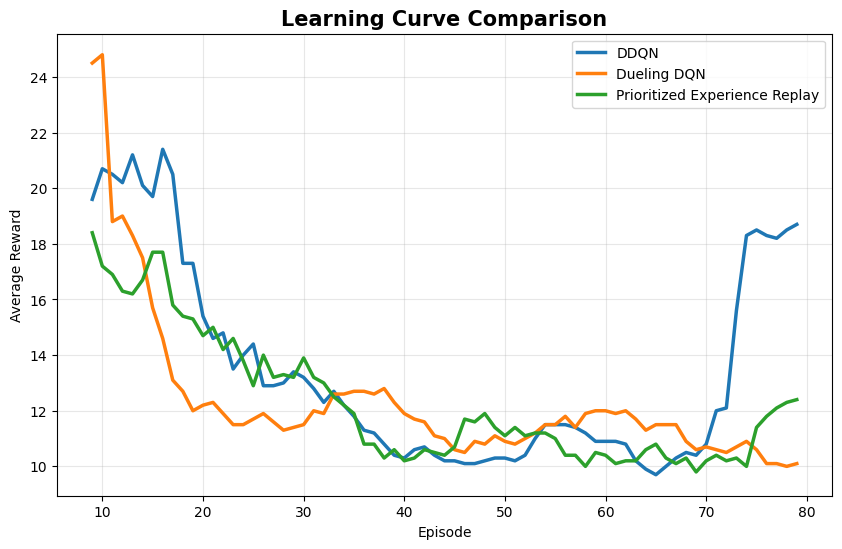

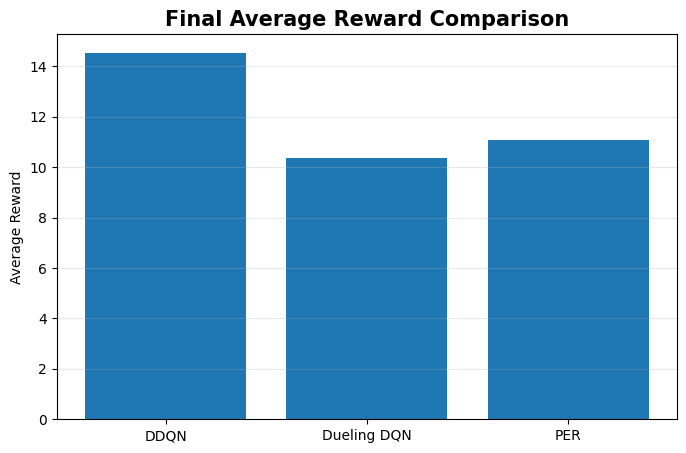

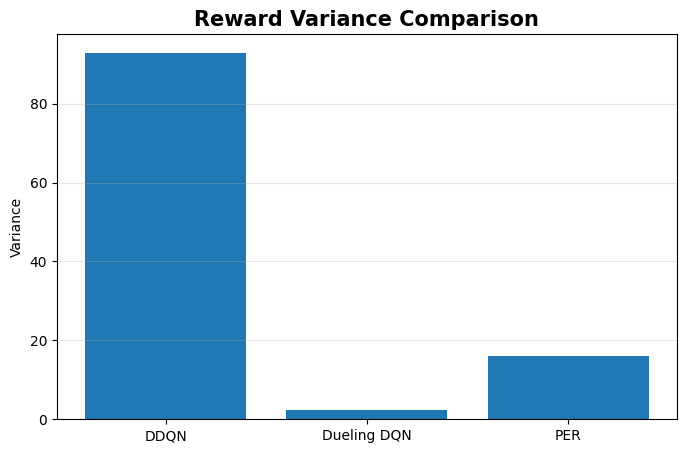

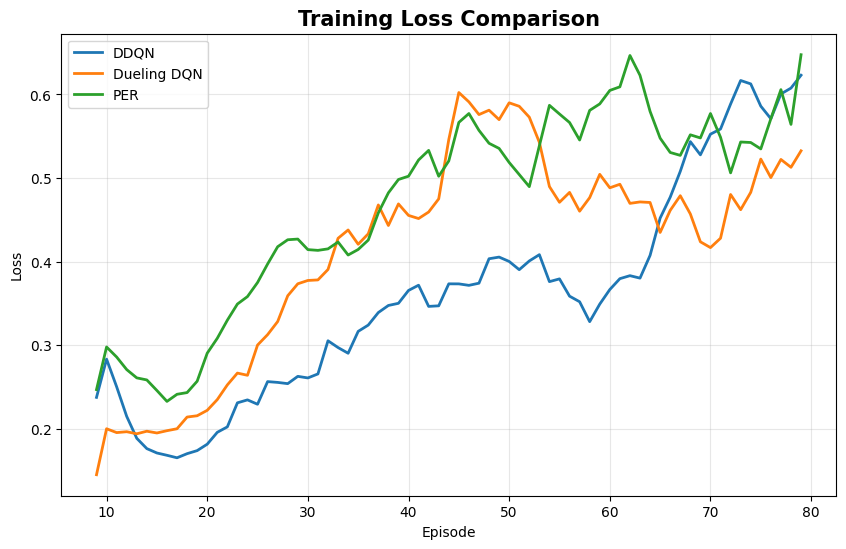

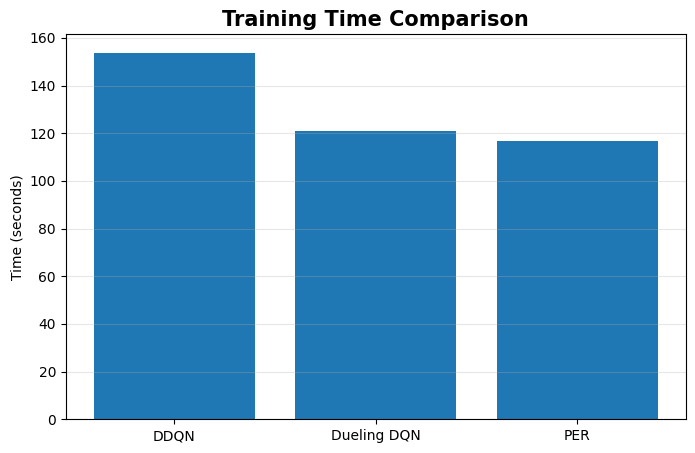



SUMMARY TABLE


,Algorithm,Final Reward,Maximum Reward,Variance,Training Time
0,DDQN,14.55,46.0,92.95,153.80
1,Dueling DQN,10.35,69.0,2.33,120.76
2,Prioritized Experience Replay,11.10,38.0,15.99,116.80




FINAL RESULT
Best Final Reward: DDQN
Lowest Variance: Dueling DQN


CONCLUSION
DDQN, Dueling DQN and Prioritized Experience Replay were evaluated using the CartPole-v1 environment.
DDQN reduces Q-value overestimation by separating action selection and evaluation.
Dueling DQN separates state value and action advantage in the network architecture.
Prioritized Experience Replay gives higher sampling importance to selected experiences.
The three variants were compared using reward, variance, training loss and training time.

Files Created:
DQN_Variants_Full_Dataset.csv
DQN_Variants_Summary.csv

Experiment 10 Completed Successfully.


In [ ]:
!pip -q install gymnasium tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense,Layer
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
import time

np.random.seed(10)
tf.random.set_seed(10)
random.seed(10)

print("="*75)
print("EXPERIMENT 10")
print("Performance Evaluation of DQN Variants")
print("DDQN, Dueling DQN and Prioritized Experience Replay")
print("="*75)

EPISODES=80
GAMMA=0.95
LR=0.001
BATCH=32
MEMORY_SIZE=3000
EPS_MIN=0.05
EPS_DECAY=0.97

class DuelingLayer(Layer):
    def __init__(self,actions):
        super().__init__()
        self.actions=actions

    def call(self,x):
        value=x[:,:1]
        advantage=x[:,1:]
        return value+(advantage-tf.reduce_mean(advantage,axis=1,keepdims=True))

def normal_model():
    model=Sequential([
        Input(shape=(4,)),
        Dense(64,activation="relu"),
        Dense(64,activation="relu"),
        Dense(2,activation="linear")
    ])
    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss="mse"
    )
    return model

def dueling_model():
    inputs=Input(shape=(4,))
    x=Dense(64,activation="relu")(inputs)
    x=Dense(64,activation="relu")(x)
    x=Dense(3)(x)
    outputs=DuelingLayer(2)(x)
    model=tf.keras.Model(inputs,outputs)
    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss="mse"
    )
    return model

def create_models(variant):
    if variant=="Dueling DQN":
        model=dueling_model()
        target=dueling_model()
    else:
        model=normal_model()
        target=normal_model()

    target.set_weights(model.get_weights())
    return model,target

def train_variant(variant):

    env=gym.make("CartPole-v1")
    model,target=create_models(variant)
    memory=deque(maxlen=MEMORY_SIZE)

    rewards=[]
    losses=[]
    epsilons=[]
    steps_list=[]

    epsilon=1.0
    start=time.time()

    for episode in range(EPISODES):

        state,_=env.reset()
        total_reward=0
        total_loss=0
        loss_count=0
        steps=0
        done=False

        while not done:

            if np.random.random()<epsilon:
                action=np.random.randint(2)
            else:
                q=model.predict(
                    np.array([state],dtype=np.float32),
                    verbose=0
                )
                action=int(np.argmax(q[0]))

            next_state,reward,terminated,truncated,_=env.step(action)
            done=terminated or truncated

            priority=abs(reward)+0.01

            memory.append(
                (
                    state,
                    action,
                    reward,
                    next_state,
                    done,
                    priority
                )
            )

            if len(memory)>=BATCH and steps%4==0:

                if variant=="Prioritized Experience Replay":

                    priorities=np.array(
                        [x[5] for x in memory],
                        dtype=np.float64
                    )

                    probabilities=priorities/priorities.sum()

                    indices=np.random.choice(
                        len(memory),
                        BATCH,
                        replace=False,
                        p=probabilities
                    )

                    batch=[memory[i] for i in indices]

                else:
                    batch=random.sample(
                        list(memory),
                        BATCH
                    )

                states=np.array(
                    [x[0] for x in batch],
                    dtype=np.float32
                )

                actions=np.array(
                    [x[1] for x in batch],
                    dtype=np.int32
                )

                rewards_batch=np.array(
                    [x[2] for x in batch],
                    dtype=np.float32
                )

                next_states=np.array(
                    [x[3] for x in batch],
                    dtype=np.float32
                )

                dones=np.array(
                    [x[4] for x in batch],
                    dtype=bool
                )

                current_q=model.predict(
                    states,
                    verbose=0
                )

                target_next_q=target.predict(
                    next_states,
                    verbose=0
                )

                if variant=="DDQN":

                    online_next_q=model.predict(
                        next_states,
                        verbose=0
                    )

                    best_actions=np.argmax(
                        online_next_q,
                        axis=1
                    )

                    targets=current_q.copy()

                    for i in range(BATCH):

                        if dones[i]:

                            targets[i,actions[i]]=rewards_batch[i]

                        else:

                            targets[i,actions[i]]=(
                                rewards_batch[i]
                                +GAMMA*
                                target_next_q[
                                    i,
                                    best_actions[i]
                                ]
                            )

                else:

                    targets=current_q.copy()

                    for i in range(BATCH):

                        if dones[i]:

                            targets[i,actions[i]]=rewards_batch[i]

                        else:

                            targets[i,actions[i]]=(
                                rewards_batch[i]
                                +GAMMA*
                                np.max(target_next_q[i])
                            )

                history=model.fit(
                    states,
                    targets,
                    epochs=1,
                    verbose=0
                )

                loss=float(
                    history.history["loss"][0]
                )

                total_loss+=loss
                loss_count+=1

            state=next_state
            total_reward+=reward
            steps+=1

        epsilon=max(
            EPS_MIN,
            epsilon*EPS_DECAY
        )

        if (episode+1)%10==0:
            target.set_weights(
                model.get_weights()
            )

        rewards.append(total_reward)

        losses.append(
            total_loss/loss_count
            if loss_count>0
            else 0
        )

        epsilons.append(epsilon)
        steps_list.append(steps)

        if (episode+1)%20==0:
            print(
                variant,
                "Episode:",
                episode+1,
                "Reward:",
                round(total_reward,2),
                "Epsilon:",
                round(epsilon,3)
            )

    env.close()

    return {
        "rewards":rewards,
        "losses":losses,
        "epsilons":epsilons,
        "steps":steps_list,
        "time":time.time()-start
    }

print("\nTraining DDQN")
ddqn=train_variant("DDQN")

print("\nTraining Dueling DQN")
dueling=train_variant("Dueling DQN")

print("\nTraining Prioritized Experience Replay")
per=train_variant("Prioritized Experience Replay")

episodes=np.arange(1,EPISODES+1)

dataset=pd.DataFrame({
    "Episode":episodes,
    "DDQN_Reward":ddqn["rewards"],
    "Dueling_DQN_Reward":dueling["rewards"],
    "PER_Reward":per["rewards"],
    "DDQN_Loss":ddqn["losses"],
    "Dueling_DQN_Loss":dueling["losses"],
    "PER_Loss":per["losses"],
    "DDQN_Epsilon":ddqn["epsilons"],
    "Dueling_DQN_Epsilon":dueling["epsilons"],
    "PER_Epsilon":per["epsilons"]
})

print("\n")
print("="*75)
print("FULL DATASET")
print("="*75)

display(dataset)

dataset.to_csv(
    "DQN_Variants_Full_Dataset.csv",
    index=False
)

ddqn_smooth=pd.Series(
    ddqn["rewards"]
).rolling(10).mean()

dueling_smooth=pd.Series(
    dueling["rewards"]
).rolling(10).mean()

per_smooth=pd.Series(
    per["rewards"]
).rolling(10).mean()

plt.figure(figsize=(10,6))

plt.plot(
    ddqn_smooth,
    label="DDQN",
    linewidth=2.5
)

plt.plot(
    dueling_smooth,
    label="Dueling DQN",
    linewidth=2.5
)

plt.plot(
    per_smooth,
    label="Prioritized Experience Replay",
    linewidth=2.5
)

plt.title(
    "Learning Curve Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ddqn_final=np.mean(
    ddqn["rewards"][-20:]
)

dueling_final=np.mean(
    dueling["rewards"][-20:]
)

per_final=np.mean(
    per["rewards"][-20:]
)

plt.figure(figsize=(8,5))

plt.bar(
    ["DDQN","Dueling DQN","PER"],
    [
        ddqn_final,
        dueling_final,
        per_final
    ]
)

plt.title(
    "Final Average Reward Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Average Reward")
plt.grid(axis="y",alpha=0.3)
plt.show()

ddqn_var=np.var(
    ddqn["rewards"][-20:]
)

dueling_var=np.var(
    dueling["rewards"][-20:]
)

per_var=np.var(
    per["rewards"][-20:]
)

plt.figure(figsize=(8,5))

plt.bar(
    ["DDQN","Dueling DQN","PER"],
    [
        ddqn_var,
        dueling_var,
        per_var
    ]
)

plt.title(
    "Reward Variance Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Variance")
plt.grid(axis="y",alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))

plt.plot(
    pd.Series(ddqn["losses"]).rolling(10).mean(),
    label="DDQN",
    linewidth=2
)

plt.plot(
    pd.Series(dueling["losses"]).rolling(10).mean(),
    label="Dueling DQN",
    linewidth=2
)

plt.plot(
    pd.Series(per["losses"]).rolling(10).mean(),
    label="PER",
    linewidth=2
)

plt.title(
    "Training Loss Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))

plt.bar(
    ["DDQN","Dueling DQN","PER"],
    [
        ddqn["time"],
        dueling["time"],
        per["time"]
    ]
)

plt.title(
    "Training Time Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Time (seconds)")
plt.grid(axis="y",alpha=0.3)
plt.show()

comparison=pd.DataFrame({
    "Algorithm":[
        "DDQN",
        "Dueling DQN",
        "Prioritized Experience Replay"
    ],
    "Final Reward":[
        round(ddqn_final,2),
        round(dueling_final,2),
        round(per_final,2)
    ],
    "Maximum Reward":[
        max(ddqn["rewards"]),
        max(dueling["rewards"]),
        max(per["rewards"])
    ],
    "Variance":[
        round(ddqn_var,2),
        round(dueling_var,2),
        round(per_var,2)
    ],
    "Training Time":[
        round(ddqn["time"],2),
        round(dueling["time"],2),
        round(per["time"],2)
    ]
})

print("\n")
print("="*75)
print("SUMMARY TABLE")
print("="*75)

display(comparison)

comparison.to_csv(
    "DQN_Variants_Summary.csv",
    index=False
)

best=comparison.loc[
    comparison["Final Reward"].idxmax(),
    "Algorithm"
]

lowest=comparison.loc[
    comparison["Variance"].idxmin(),
    "Algorithm"
]

print("\n")
print("="*75)
print("FINAL RESULT")
print("="*75)

print("Best Final Reward:",best)
print("Lowest Variance:",lowest)

print("\n")
print("="*75)
print("CONCLUSION")
print("="*75)

print(
    "DDQN, Dueling DQN and Prioritized Experience Replay "
    "were evaluated using the CartPole-v1 environment."
)

print(
    "DDQN reduces Q-value overestimation by separating "
    "action selection and evaluation."
)

print(
    "Dueling DQN separates state value and action advantage "
    "in the network architecture."
)

print(
    "Prioritized Experience Replay gives higher sampling "
    "importance to selected experiences."
)

print(
    "The three variants were compared using reward, "
    "variance, training loss and training time."
)

print("\nFiles Created:")
print("DQN_Variants_Full_Dataset.csv")
print("DQN_Variants_Summary.csv")

print("\nExperiment 10 Completed Successfully.")